<a href="https://colab.research.google.com/github/alexsandoval05/Revenue-sustainability-Chrysal/blob/main/chrysal_profit_sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Análisis de utilidades de implementación de proyectos de sostenibilidad en Chrysal**
OBJETIVO: Definir rentabilidad anual en la implementación de proyectos de sostenibilidad y revisar si la inversion esta generando mayores ingresos.

## 1. 🧩 **Cargar y Explorar - Visión General**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales = pd.read_csv("/content/Tabla1_Chrysal_Sustainability.csv")
marketing = pd.read_csv("/content/Tabla2_Marketing_Campaign.csv")
costs = pd.read_csv("/content/Tabla3_Costs.csv")

In [ ]:
sales_clean = sales.copy()
marketing_clean = marketing.copy()
costs_clean = costs.copy()

In [ ]:
sales_clean.head()

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,173574.63,1
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5


In [ ]:
sales_clean["Date"] = pd.to_datetime(sales_clean["date"], errors="coerce", utc=True)
sales_clean["Year"]  = sales_clean["Date"].dt.year
sales_clean["Month"] = sales_clean["Date"].dt.month
sales_clean.head()

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id,Date,Year,Month
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2,2025-01-01 00:00:00+00:00,2025,1
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3,2022-05-01 00:00:00+00:00,2022,5
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4,2024-05-01 00:00:00+00:00,2024,5
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5,2024-04-01 00:00:00+00:00,2024,4


In [ ]:
sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   700 non-null    object             
 1   date                 700 non-null    object             
 2   country              700 non-null    object             
 3   product_reference    700 non-null    object             
 4   campaign_id          700 non-null    int64              
 5   category_product     700 non-null    object             
 6   sales_revenue_usd    630 non-null    float64            
 7   production_cost_usd  700 non-null    float64            
 8   customer_id          700 non-null    int64              
 9   Date                 700 non-null    datetime64[ns, UTC]
 10  Year                 700 non-null    int32              
 11  Month                700 non-null    int32              
dtypes: datetime64[ns, UTC]

In [ ]:
sales_clean.nunique()

,0
sales_order_number,700
date,20
country,4
product_reference,5
campaign_id,4
category_product,5
sales_revenue_usd,630
production_cost_usd,700
customer_id,700
Date,20


In [ ]:
marketing_clean.head()

,Marketing_cost,Campaign_ID,Marketing_campaign_type
0,11000.0,4,Social Media
1,3000.0,3,Influencers Agro
2,11000.0,4,Social Media
3,3000.0,3,Influencers Agro
4,60000.0,2,Field Campaign


In [ ]:
marketing_clean["Marketing_campaign_type"].value_counts()

,count
Marketing_campaign_type,
Social Media,2
Influencers Agro,2
Field Campaign,2
Email Marketing,2


In [ ]:
marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marketing_cost           8 non-null      float64
 1   Campaign_ID              8 non-null      int64  
 2   Marketing_campaign_type  8 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
costs_clean.head()

,Sales_order_number,Product_reference,Production_cost,Waste_kg,Disposal_waste_cost
0,SO-000001,Chrysal Grow X,57858.21,750.32,375.160
1,SO-000002,Chrysal Flora F,18200.66,209.94,104.970
2,SO-000003,Chrysal Flora F,101783.75,882.49,441.245
3,SO-000004,Chrysal Flora F,73680.46,982.56,491.280
4,SO-000005,Chrysal Grow X,78617.18,582.48,291.240


In [ ]:
costs_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    object 
 1   Product_reference    700 non-null    object 
 2   Production_cost      700 non-null    float64
 3   Waste_kg             665 non-null    float64
 4   Disposal_waste_cost  665 non-null    float64
dtypes: float64(3), object(2)
memory usage: 27.5+ KB


In [ ]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Production_cost,700
Waste_kg,664
Disposal_waste_cost,664


## **1.2 🧩 Identificación de problemas de calidad de datos**
Calcule la cantidad de vacios en "sales" y "costs"

In [ ]:
sales_clean.isna().sum()
print('Porcentaje de nulos',sales_clean.isna().sum())
print('Porcentaje de nulos',sales_clean.isna().mean())

Porcentaje de nulos sales_order_number      0
date                    0
country                 0
product_reference       0
campaign_id             0
category_product        0
sales_revenue_usd      70
production_cost_usd     0
customer_id             0
Date                    0
Year                    0
Month                   0
dtype: int64
Porcentaje de nulos sales_order_number     0.0
date                   0.0
country                0.0
product_reference      0.0
campaign_id            0.0
category_product       0.0
sales_revenue_usd      0.1
production_cost_usd    0.0
customer_id            0.0
Date                   0.0
Year                   0.0
Month                  0.0
dtype: float64


In [ ]:
costs_clean.isna().sum()
print('Porcentaje de nulos',costs_clean.isna().sum())
print('Porcentaje de nulos',costs_clean.isna().mean())


Porcentaje de nulos Sales_order_number      0
Product_reference       0
Production_cost         0
Waste_kg               35
Disposal_waste_cost    35
dtype: int64
Porcentaje de nulos Sales_order_number     0.00
Product_reference      0.00
Production_cost        0.00
Waste_kg               0.05
Disposal_waste_cost    0.05
dtype: float64


In [ ]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Production_cost,700
Waste_kg,664
Disposal_waste_cost,664


# **2- Estadistica Descriptiva**

In [ ]:
print("sales",sales_clean.describe())
print("marketing",marketing_clean.describe())
print("costs",costs_clean.describe())

sales        campaign_id  sales_revenue_usd  production_cost_usd  customer_id  \
count   700.000000         630.000000           700.000000    700.00000   
mean      2.537143       94651.089063         76815.294357    350.50000   
std       1.130937       51459.167383         66495.256676    202.21688   
min       1.000000        4838.780000          2585.940000      1.00000   
25%       2.000000       52970.632500         31897.205000    175.75000   
50%       3.000000       95928.995000         60863.210000    350.50000   
75%       4.000000      134256.020000         92603.350000    525.25000   
max       4.000000      222096.760000        400616.430000    700.00000   

              Year       Month  
count   700.000000  700.000000  
mean   2023.560000    2.997143  
std       1.136267    1.447208  
min    2022.000000    1.000000  
25%    2023.000000    2.000000  
50%    2024.000000    3.000000  
75%    2025.000000    4.000000  
max    2025.000000    5.000000  
marketing        Mark

**HALLAZGOS:**
- **Sales Revenue USD**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es el doble del "75%"
- **Production_cost**: Es posible sistribucion normal pero se debe descartar con histograma
- **Waste_kg** y **Disposal_waste_cost**: Posible distribucion con sesgos o "outlier"a la izquierda ya que el min es 10 veces menor que el "25%"

## **2.1 Analisis complementario**
### **2.1.1 Realice pruebas de comparacion de media y mediana** para entender la tendencia de "Sales_revenue_USD" y "production_costs" en tabla de "sales_clean"

In [ ]:
columnas_numericas_sales = sales_clean[['sales_revenue_usd', 'production_cost_usd']]

for col in columnas_numericas_sales:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", columnas_numericas_sales[col].mean(),"- Mediana:", columnas_numericas_sales[col].median())
    print()

sales_revenue_usd
Promedio 94651.08906349207 - Mediana: 95928.995

production_cost_usd
Promedio 76815.29435714285 - Mediana: 60863.21



## **CONCLUSIONES:**

- Se evidencia ligera tendencia de sesgo a la derecha para "Sales_revenue_USD" por tal razon los datos vacios se reemplazaran por la mediana.
- En "production_cost_usd" si se evidencia diferencia sifnificativa entre mediana y promedio.



### 2.1.3 Realice evaluacion **agrupando por año y pais** para revisar dominancia en la columna "Sales_revenue_USD"

In [ ]:
resumen_pais = (
    sales_clean
    .groupby(['country', 'Year'])
    .agg(
        avg_sales=('sales_revenue_usd', 'mean'),
        count_sales=('sales_revenue_usd', 'count'),
        desv_sales=('sales_revenue_usd', 'std'),
        min_sales=('sales_revenue_usd', 'min'),
        max_sales=('sales_revenue_usd', 'max'),

    )
    .reset_index()
)
resumen_pais

,country,Year,avg_sales,count_sales,desv_sales,min_sales,max_sales
0,Colombia,2022,89852.641515,33,50148.873551,13230.36,176983.83
1,Colombia,2023,89426.186154,39,51614.766564,13064.64,180848.44
2,Colombia,2024,112120.543158,38,57058.053383,6342.83,194085.76
3,Colombia,2025,95596.203077,39,55196.544372,8086.54,195064.00
4,Ecuador,2022,93842.490769,39,58125.263618,10992.52,222096.76
5,Ecuador,2023,94175.773261,46,53813.524831,5427.42,217312.03
6,Ecuador,2024,95799.619333,45,45223.315753,14898.64,188013.75
7,Ecuador,2025,91342.477778,45,54085.669181,5719.70,190712.14
8,Holanda,2022,92638.347179,39,47829.785241,10447.40,181871.75
9,Holanda,2023,93676.323429,35,54410.473785,4838.78,213030.15


**CONCLUSIONES**:

No se evidencia dominancia de tendencia por año y pais.

In [ ]:
columnas_categoricas_1 = sales_clean[['country','product_reference','category_product']]
columnas_categoricas_2 = marketing_clean[['Marketing_campaign_type']]

print(columnas_categoricas_1.describe())
print(columnas_categoricas_2.describe())


        country product_reference category_product
count       700               700              700
unique        4                 5                5
top     Ecuador   Chrysal Flora F      Nutricional
freq        188               154              157
       Marketing_campaign_type
count                        8
unique                       4
top               Social Media
freq                         2


In [ ]:
for col in columnas_categoricas_1:
    print(col)
    print(sales_clean[col].value_counts())
    print()

country
country
Ecuador     188
Colombia    177
Holanda     175
Kenya       160
Name: count, dtype: int64

product_reference
product_reference
Chrysal Flora F      154
Chrysal Root R       149
Chrysal Protect Y    148
Chrysal Grow X       139
Chrysal Boost Z      110
Name: count, dtype: int64

category_product
category_product
Nutricional                 157
Fertilizante                145
Insecticida                 140
Regulador de crecimiento    133
Fungicida                   125
Name: count, dtype: int64



In [ ]:
print(marketing_clean["Marketing_campaign_type"].value_counts())

Marketing_campaign_type
Social Media        2
Influencers Agro    2
Field Campaign      2
Email Marketing     2
Name: count, dtype: int64


**CONCLUSION DE ANALISIS:**




De acuerdo a este conteo de columnas **categoricas dominantes**  **NO** se evidencia una afectacion especifica por alguna categoria evaluada.

## **3- Visualizacion Diagnóstica**

In [ ]:
sales_paises = sales_clean[(sales_clean['country']=='Colombia') |
                  (sales_clean['country']=='Holanda') |
                  (sales_clean['country']=='Kenya') |
                  (sales_clean['country']=='Ecuador')
]
sales_paises

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id,Date,Year,Month
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2,2025-01-01 00:00:00+00:00,2025,1
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3,2022-05-01 00:00:00+00:00,2022,5
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4,2024-05-01 00:00:00+00:00,2024,5
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5,2024-04-01 00:00:00+00:00,2024,4
...,...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,2025-02-01,Colombia,Chrysal Boost Z,3,Fertilizante,134575.02,74479.46,696,2025-02-01 00:00:00+00:00,2025,2
696,SO-000697,2024-01-01,Holanda,Chrysal Grow X,2,Fertilizante,137243.67,255123.48,697,2024-01-01 00:00:00+00:00,2024,1
697,SO-000698,2023-05-01,Ecuador,Chrysal Root R,3,Nutricional,70017.12,41102.49,698,2023-05-01 00:00:00+00:00,2023,5
698,SO-000699,2023-03-01,Colombia,Chrysal Flora F,1,Insecticida,180848.44,91872.60,699,2023-03-01 00:00:00+00:00,2023,3


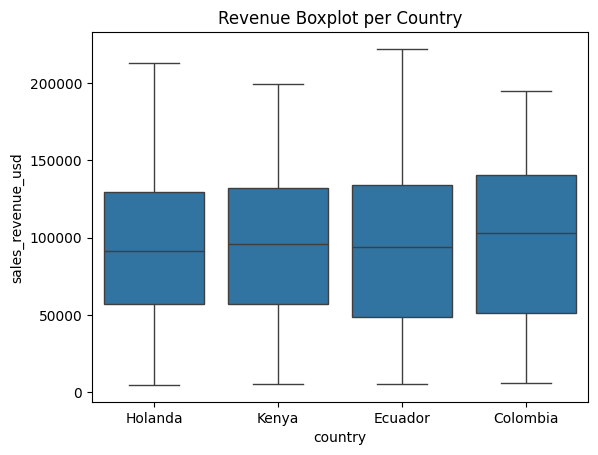

In [ ]:
sns.boxplot(data=sales_paises, x="country", y="sales_revenue_usd")
plt.title(f'Revenue Boxplot per Country')
plt.show()


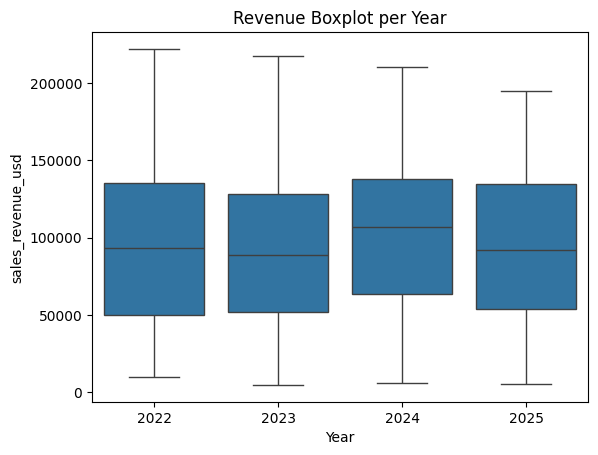

In [ ]:
sns.boxplot(data=sales_paises, x="Year", y="sales_revenue_usd")
plt.title(f'Revenue Boxplot per Year')
plt.show()


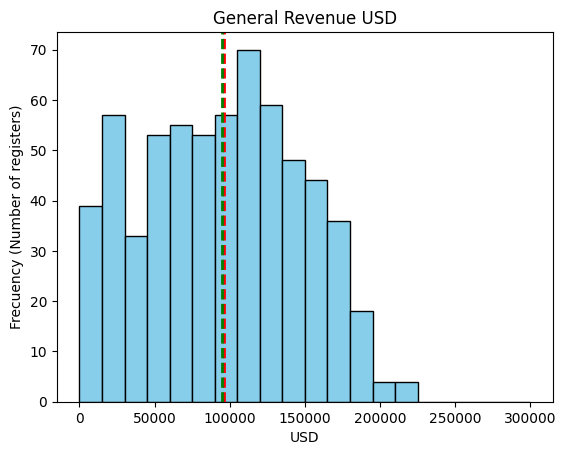

In [ ]:

plt.hist(sales_clean['sales_revenue_usd'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['sales_revenue_usd'].median()
average_sales = sales_clean['sales_revenue_usd'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Revenue USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

##4- Identificacion formal de Outliers

##5 - Limpieza automatica por pipeline

In [ ]:
sales_clean['sales_revenue_usd'] = sales_clean['sales_revenue_usd'].fillna(sales_clean['sales_revenue_usd'].median())
print('Porcentaje de nulos',sales_clean.isna().sum())

Porcentaje de nulos sales_order_number     0
date                   0
country                0
product_reference      0
campaign_id            0
category_product       0
sales_revenue_usd      0
production_cost_usd    0
customer_id            0
Date                   0
Year                   0
Month                  0
dtype: int64


##7- Unificación tabla de interes para calculos de **% Profit y % ROI**.

- Agregue a la tabla de "Sales_clean" la tabla de "Costs"

In [ ]:
costs.rename(columns={'Sales_order_number': 'sales_order_number'}, inplace=True)
costs_clean = costs.copy()

sales_clean_small = sales_clean[['sales_order_number','sales_revenue_usd','Year','production_cost_usd','country','product_reference']]

sales_final = pd.merge(sales_clean_small, costs_clean, on=['sales_order_number'], how='left')

sales_final.head()

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Production_cost,Waste_kg,Disposal_waste_cost
0,SO-000001,127316.56,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,57858.21,750.32,375.160
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,18200.66,209.94,104.970
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,101783.75,882.49,441.245
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,73680.46,982.56,491.280
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,78617.18,582.48,291.240


In [ ]:
sales_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sales_order_number   700 non-null    object 
 1   sales_revenue_usd    700 non-null    float64
 2   Year                 700 non-null    int32  
 3   production_cost_usd  700 non-null    float64
 4   country              700 non-null    object 
 5   product_reference    700 non-null    object 
 6   Product_reference    700 non-null    object 
 7   Production_cost      700 non-null    float64
 8   Waste_kg             665 non-null    float64
 9   Disposal_waste_cost  665 non-null    float64
dtypes: float64(5), int32(1), object(4)
memory usage: 52.1+ KB


In [ ]:
sales_final['costo_total'] = sales_final['production_cost_usd'] + sales_final['Disposal_waste_cost']
sales_final['gross_profit'] = sales_final['sales_revenue_usd'] - sales_final['costo_total']
sales_final['margin_pct'] = (sales_final['gross_profit']) *100 / sales_final['sales_revenue_usd']
sales_final

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Production_cost,Waste_kg,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,127316.56,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,57858.21,750.32,375.160,173949.790,-46633.230,-36.627780
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,18200.66,209.94,104.970,18305.630,9794.460,34.855618
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,101783.75,882.49,441.245,102224.995,119871.765,53.972766
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,73680.46,982.56,491.280,74171.740,40317.040,35.214839
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,78617.18,582.48,291.240,78908.420,61486.220,43.795276
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,134575.02,2025,74479.46,Colombia,Chrysal Boost Z,Chrysal Boost Z,74479.46,605.26,302.630,74782.090,59792.930,44.430928
696,SO-000697,137243.67,2024,255123.48,Holanda,Chrysal Grow X,Chrysal Grow X,85041.16,669.30,334.650,255458.130,-118214.460,-86.134727
697,SO-000698,70017.12,2023,41102.49,Ecuador,Chrysal Root R,Chrysal Root R,41102.49,846.95,423.475,41525.965,28491.155,40.691698
698,SO-000699,180848.44,2023,91872.60,Colombia,Chrysal Flora F,Chrysal Flora F,91872.60,2069.15,1034.575,92907.175,87941.265,48.627052


In [ ]:
profit_percent_year = (
    sales_final
    .groupby(['Year'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_year

,Year,avg_profit_pct,gross_profit_USD
0,2022,17.039401,2692.225345
1,2023,21.071001,3455.644216
2,2024,16.303476,2559.645782
3,2025,12.147293,2259.396503


In [ ]:
profit_percent_country = (
    sales_final
    .groupby(['country'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_country

,country,avg_profit_pct,gross_profit_USD
0,Colombia,45.569323,7382.230255
1,Ecuador,45.116696,8030.771923
2,Holanda,-67.116285,-11409.768382
3,Kenya,44.926955,6963.678050


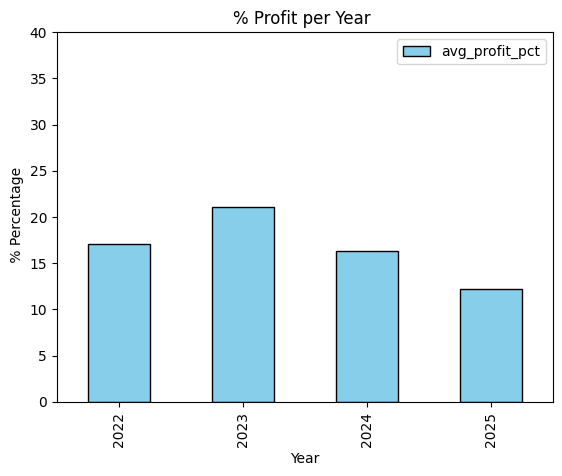

In [ ]:
profit_percent_year.plot(x='Year', y=['avg_profit_pct'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('% Profit per Year ')
plt.ylabel(' % Percentage')
plt.ylim(0,40)
plt.show()

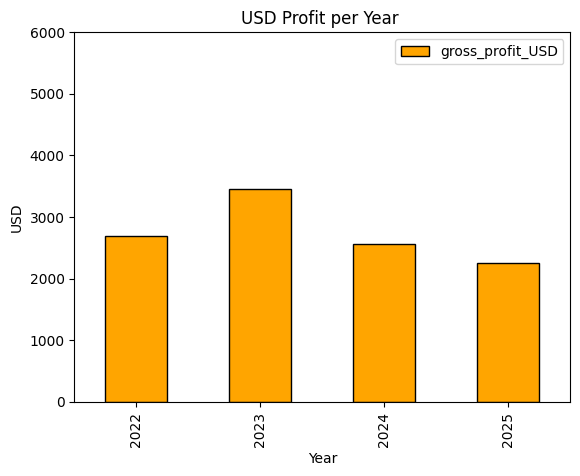

In [ ]:
profit_percent_year.plot(x='Year', y=['gross_profit_USD'], kind='bar', color='orange', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Year ')
plt.ylabel('USD')
plt.ylim(0,6000)
plt.show()

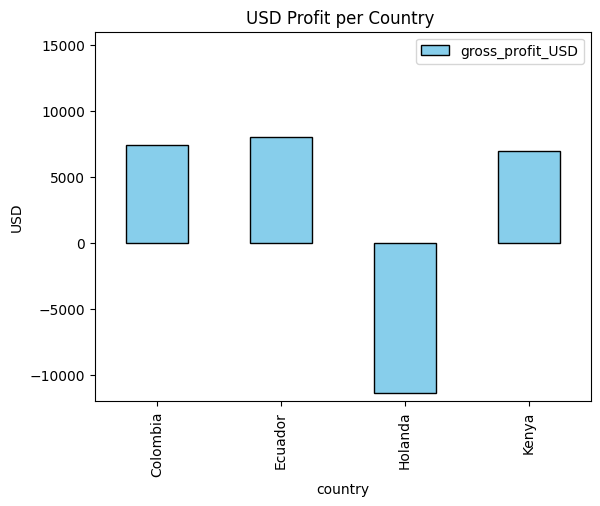

In [ ]:
profit_percent_country.plot(x='country', y=['gross_profit_USD'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Country ')
plt.ylabel('USD')
plt.ylim(-12000,16000)
plt.show()

**🧩CONCLUSIONES:**
- Se evidencia que Holanda ha tenido perdidas por cuantia de -U$10.000 con respecto a utilidades de USD 7.000 que han presentado cada una de las otras sedes como Colombia, Ecuador y Kenya posiblmente por altos costos operacionales de Holanda y nuevas tendencias del mercado floricultor.
- A nivel global las utilidades de toda la compañia fueron del 21% en 2023 y ha tenido una tendencia ha disminuir en el 2024 y 2025 con utilidadesdes del 16  y 12 % respectivamente.

In [ ]:
sales_final.head()

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Production_cost,Waste_kg,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,127316.56,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,57858.21,750.32,375.160,173949.790,-46633.230,-36.627780
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,18200.66,209.94,104.970,18305.630,9794.460,34.855618
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,101783.75,882.49,441.245,102224.995,119871.765,53.972766
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,73680.46,982.56,491.280,74171.740,40317.040,35.214839
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,78617.18,582.48,291.240,78908.420,61486.220,43.795276


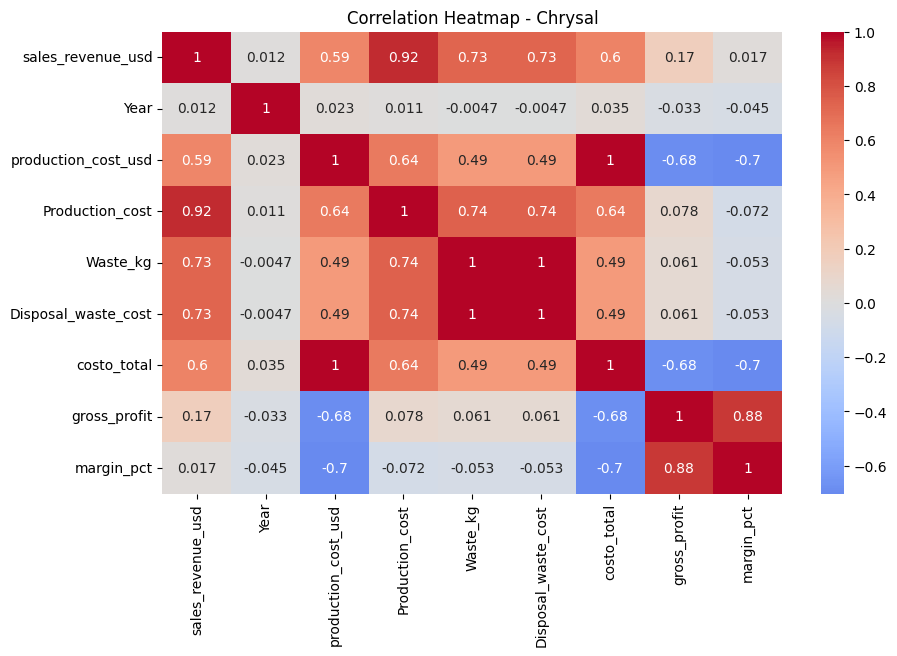

In [ ]:
numeric_sales_final = sales_final.select_dtypes(include=np.number)
corr_matrix = numeric_sales_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Chrysal")
plt.show()

In [ ]:
sales_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Chrysal")
plt.show()

ValueError: could not convert string to float: 'SO-000001'